In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
pd.options.mode.copy_on_write = True

In [2]:
def _load_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0)
    idx = pd.to_datetime(df.index, errors="coerce")
    df.index = idx.to_period("M").to_timestamp("M")
    df.index.name = "date"
    df = df.sort_index()

    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(axis=1, how="all")

    return df.astype("float32")

DATA_FREQ = "M"

rets    = _load_df("sp500_returns_with_tickers.csv")
caps    = _load_df("sp500_market_caps.csv")
webc    = _load_df("ebc_weights.csv")
retsebc = _load_df("equal_beta_portfolio_return.csv")
hrp     = _load_df("hrp_returns_trimmed.csv")

print("Loaded:",
      "rets", rets.shape,
      "caps", caps.shape,
      "webc", webc.shape,
      "retsebc", retsebc.shape,
      "hrp", hrp.shape)

Loaded: rets (780, 1862) caps (780, 1863) webc (696, 1596) retsebc (696, 1) hrp (659, 1)


In [3]:
# Align intersection of dates and tickers
common_index = rets.index.intersection(caps.index)
common_cols  = rets.columns.intersection(caps.columns)
rets = rets.loc[common_index, common_cols].sort_index()
caps = caps.loc[common_index, common_cols].sort_index()

print("After resample:", rets.shape, caps.shape)

After resample: (780, 1862) (780, 1862)


In [4]:
# Cap weights
cap_weights = caps.div(caps.sum(axis=1), axis=0).fillna(0.0)
ret_cap = (rets * cap_weights).sum(axis=1).astype("float32")
ret_cap.name = "ret_cap"

print("ret_cap:", ret_cap.shape, "nan%", ret_cap.isna().mean()*100)

ret_cap: (780,) nan% 0.0


In [5]:
# Equal Weights
n_active = caps.notna().sum(axis=1)
ew_weights = caps.notna().astype("float32").div(n_active, axis=0).fillna(0.0)

ret_eq = (rets * ew_weights).sum(axis=1).astype("float32")
ret_eq.name = "ret_eq"

print("ret_eq:", ret_eq.shape, "nan%", ret_eq.isna().mean()*100)

ret_eq: (780,) nan% 0.0


In [6]:
# EBC
ebc = retsebc.iloc[:, 0].rename("ebc")
print("ebc:", ebc.shape, "nan%", ret_eq.isna().mean()*100)

ebc: (696,) nan% 0.0


In [7]:
# HRP
hrp = hrp.squeeze()
print("hrp:", hrp.shape, "nan%", ret_eq.isna().mean()*100)
hrp

hrp: (659,) nan% 0.0


date
1970-02-28    0.064960
1970-03-31    0.011168
1970-04-30   -0.084579
1970-05-31   -0.066997
1970-06-30   -0.044760
                ...   
2024-08-31    0.041952
2024-09-30    0.015083
2024-10-31   -0.018519
2024-11-30    0.051883
2024-12-31   -0.058851
Freq: ME, Name: HRP, Length: 659, dtype: float32

In [8]:
ports = pd.concat(
    [
        ret_cap.rename("cw"),
        (ret_cap - ebc).rename("cw-ebc"),
        (ret_cap - ret_eq).rename("cw-ew"),
        (ret_cap - hrp).rename("cw-hrp"),
    ],
    axis=1
).dropna()

print("Portfolio returns:", ports.shape, "|", ports.index.min(), "→", ports.index.max())
display(ports.head())

Portfolio returns: (659, 4) | 1970-02-28 00:00:00 → 2024-12-31 00:00:00


,cw,cw-ebc,cw-ew,cw-hrp
date,,,,
1970-02-28,0.063582,-0.002313,-0.005010,-0.001378
1970-03-31,0.005553,-0.008208,0.002469,-0.005615
1970-04-30,-0.085739,0.008140,0.023062,-0.001160
1970-05-31,-0.049981,0.021586,0.032337,0.017017
1970-06-30,-0.043239,0.004287,0.015615,0.001521


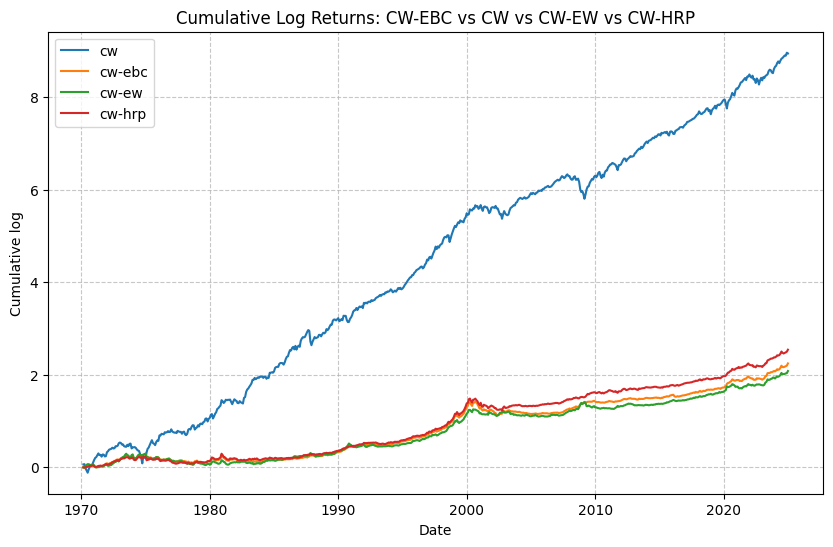

In [9]:
df = ports[["cw", "cw-ebc", "cw-ew","cw-hrp"]].dropna().sort_index()
cum = np.log1p(df).cumsum()

plt.figure(figsize=(10,6))
for col in cum.columns:
    plt.plot(cum.index, cum[col], label=col)
plt.title("Cumulative Log Returns: CW-EBC vs CW vs CW-EW vs CW-HRP")
plt.xlabel("Date")
plt.ylabel("Cumulative log")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [10]:
ff5 = pd.read_csv("F-F_Research_Data_5_Factors_2x3.csv", skiprows =3, nrows =742)
ff5.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ff5["Date"] = pd.to_datetime(ff5["Date"], format="%Y%m")
ff5.set_index("Date", inplace=True)
ff5 = ff5.astype(float) / 100

ffm = pd.read_csv("F-F_Momentum_Factor.csv",skiprows= 13, nrows = 1180)
ffm.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ffm["Date"] = pd.to_datetime(ffm["Date"], format="%Y%m")
ffm.set_index("Date", inplace=True)
ffm = ffm.astype(float) / 100

ff = ff5.join(ffm, how="inner")
ff

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
Date,,,,,,,
1963-07-01,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08-01,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09-01,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10-01,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11-01,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078
...,...,...,...,...,...,...,...
2024-12-01,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037,-0.0030
2025-01-01,0.0280,-0.0122,0.0162,-0.0233,-0.0324,0.0037,0.0095
2025-02-01,-0.0243,-0.0493,0.0491,0.0109,0.0306,0.0033,-0.0082


In [11]:
ports_p = ports.copy()
ff_p    = ff.copy()
ports_p.index = pd.PeriodIndex(pd.to_datetime(ports_p.index), freq="M")
ff_p.index    = pd.PeriodIndex(pd.to_datetime(ff_p.index),    freq="M")

pref = ports[["cw", "cw-ew", "cw-ebc", "cw-hrp"]].copy()
pref_p = pref.copy()
pref_p.index = pref_p.index.to_period("M")

idx_p = pref_p.index.intersection(ff_p.index)
pref_p = pref_p.loc[idx_p].astype(float)
ff_p   = ff_p.loc[idx_p].astype(float)

print("Aligned (PeriodIndex) span:", idx_p.min(), "→", idx_p.max(), "| rows:", len(idx_p))

pref_m = pref_p.copy()
ff_m   = ff_p.copy()
pref_m.index = pref_m.index.to_timestamp(how="end")
ff_m.index   = ff_m.index.to_timestamp(how="end")

Aligned (PeriodIndex) span: 1970-02 → 2024-12 | rows: 659


In [12]:
df_aligned = pd.concat(
    [
        pref_m[["cw-ebc", "cw-ew", "cw-hrp"]],
        ff_m[["Mkt-RF","SMB", "HML", "RMW", "CMA", "Mom"]],
    ],
    axis=1,
).dropna()

desc = df_aligned[["cw-ebc", "cw-ew", "cw-hrp"]].describe().T[["mean", "std", "min", "max"]]
desc["Sharpe_annual"] = desc["mean"] / desc["std"] * np.sqrt(12)
display(desc)

print("Corrs:")
corrs = df_aligned.corr().loc[
    ["cw-ebc", "cw-ew", "cw-hrp"], [ "Mkt-RF","SMB", "HML", "RMW", "CMA", "Mom"]
]
display(corrs)

,mean,std,min,max,Sharpe_annual
cw-ebc,0.003546,0.016395,-0.081846,0.082725,0.749261
cw-ew,0.003309,0.017127,-0.092538,0.083511,0.669203
cw-hrp,0.003997,0.016271,-0.071637,0.083200,0.850856


Corrs:


,Mkt-RF,SMB,HML,RMW,CMA,Mom
cw-ebc,0.067716,-0.359429,-0.540443,-0.115234,-0.423778,0.256562
cw-ew,-0.290522,-0.588584,-0.383434,0.096333,-0.190932,0.443138
cw-hrp,0.332196,-0.188601,-0.494236,-0.225154,-0.463582,0.081753


# Factor Control

In [13]:
factors = ["SMB", "HML", "RMW", "CMA", "Mom"]
#factors = ["Mkt-RF","SMB", "HML", "RMW", "CMA", "Mom"]

In [14]:
ff_m = ff_m.copy()
ff_m.index = pd.PeriodIndex(pd.to_datetime(ff_m.index, errors="coerce"), freq="M").to_timestamp("M")
ff_m.sort_index(inplace=True)

In [15]:
missing = [c for c in factors if c not in ff_p.columns]

idx_p = ports_p.index.intersection(ff_p.index)

panel = pd.concat(
    [ports_p.loc[idx_p, ["cw", "cw-ebc", "cw-ew", "cw-hrp"]].astype("float32"),
     ff_p.loc[idx_p, factors].astype("float32")],
    axis=1
).dropna()

print("Panel:", panel.shape, "|", panel.index.min(), "→", panel.index.max())
panel.head()

Panel: (659, 9) | 1970-02 → 2024-12


,cw,cw-ebc,cw-ew,cw-hrp,SMB,HML,RMW,CMA,Mom
1970-02,0.063582,-0.002313,-0.005010,-0.001378,-0.0257,0.0369,-0.0241,0.0287,0.0027
1970-03,0.005553,-0.008208,0.002469,-0.005615,-0.0242,0.0408,-0.0106,0.0442,-0.0036
1970-04,-0.085739,0.008140,0.023062,-0.001160,-0.0634,0.0614,-0.0063,0.0590,-0.0083
1970-05,-0.049981,0.021586,0.032337,0.017017,-0.0446,0.0332,-0.0129,0.0379,-0.0266
1970-06,-0.043239,0.004287,0.015615,0.001521,-0.0210,0.0044,0.0014,0.0271,0.0564


In [16]:
# -------- Cell N: FF6 regressions (OLS + HAC) and tidy outputs --------
from collections import OrderedDict

def ff6_reg(df, yname, maxlags=6):
    y_ex = df[yname]
    X = sm.add_constant(df[factors])
    model = sm.OLS(y_ex, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return model

def pack_row(name, model, factors=None):
    if factors is None:
        factors = factors

    params = model.params
    tvals  = model.tvalues

    out = OrderedDict()
    out["strategy"] = name

    # alpha（const）
    if "const" in params.index:
        alpha_m = float(params["const"])
        out["alpha_ann_%"] = ((1.0 + alpha_m)**12 - 1.0) * 100.0
        out["t_alpha(NW)"] = float(tvals["const"])
    else:
        out["alpha_ann_%"] = np.nan
        out["t_alpha(NW)"] = np.nan

    for f in factors:
        out[f"beta_{f}"] = float(params.get(f, np.nan))
        out[f"t_{f}"]    = float(tvals.get(f, np.nan))

    out["R2"]  = float(model.rsquared)
    out["Obs"] = int(getattr(model, "nobs", len(model.model.endog)))
    return pd.Series(out)

def print_summary_no_datetime(title, model):
    txt = model.summary().as_text()
    lines = []
    for ln in txt.splitlines():
        if ln.strip().startswith("Date:") or ln.strip().startswith("Time:"):
            continue
        lines.append(ln)
    print("="*86)
    print(title)
    print("="*86)
    print("\n".join(lines))
    print()

res_ew  = ff6_reg(panel, "cw-ew", maxlags=6)
res_ebc = ff6_reg(panel, "cw-ebc", maxlags=6)
res_hrp = ff6_reg(panel, "cw-hrp", maxlags =6)

print_summary_no_datetime("FF6 Regression: CW − EW",  res_ew)
print_summary_no_datetime("FF6 Regression: CW − EBC", res_ebc)
print_summary_no_datetime("FF6 Regression: CW − HRP", res_hrp)

summary_df = pd.DataFrame([
    pack_row("CW-EW",  res_ew, factors=factors),
    pack_row("CW-EBC", res_ebc, factors=factors),
    pack_row("CW-HRP", res_hrp, factors=factors)
]).set_index("strategy")

display(summary_df.round(3))

FF6 Regression: CW − EW
                            OLS Regression Results                            
Dep. Variable:                  cw-ew   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     105.0
No. Observations:                 659   AIC:                            -4085.
Df Residuals:                     653   BIC:                            -4058.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0038      0.000      7.739      0.000       0.003       0.005
SMB           -0.3347      0.030    -11.317      0.000      -0.393      -0.277
HML           -0.1528      0

,alpha_ann_%,t_alpha(NW),beta_SMB,t_SMB,beta_HML,t_HML,beta_RMW,t_RMW,beta_CMA,t_CMA,beta_Mom,t_Mom,R2,Obs
strategy,,,,,,,,,,,,,,
CW-EW,4.604,7.739,-0.335,-11.317,-0.153,-5.001,-0.086,-1.608,-0.036,-0.940,0.132,5.284,0.601,659
CW-EBC,6.167,9.110,-0.239,-8.466,-0.172,-5.384,-0.175,-3.271,-0.178,-4.570,0.064,2.253,0.500,659
CW-HRP,7.240,9.324,-0.169,-6.505,-0.126,-3.658,-0.215,-4.348,-0.243,-5.122,0.012,0.373,0.390,659


In [17]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def rolling_bfm(
    rets: pd.DataFrame,
    ff: pd.DataFrame,
    pref_series: pd.Series | None = None,
    *,
    window: int = 60,
    ridge: None | float | str = "auto",
    orthogonalize: bool = False,
    factors: list[str],              
    nw_maxlags: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    def to_mend(idx):
        idx = pd.to_datetime(idx, errors="coerce")
        return pd.PeriodIndex(idx, freq="M").to_timestamp("M")
    rets_ = rets.copy(); rets_.index = to_mend(rets_.index)
    ff_   = ff.copy();   ff_.index   = to_mend(ff_.index)
    has_pref = pref_series is not None
    if has_pref:
        pref_ = pd.to_numeric(pref_series.copy(), errors="coerce")
        pref_.index = to_mend(pref_.index)

    idx = rets_.index.intersection(ff_.index) if not has_pref else rets_.index.intersection(ff_.index).intersection(pref_.index)
    rets_ = rets_.loc[idx].astype("float64")
    F6    = ff_.loc[idx, factors].astype("float64")
    RF    = ff_.loc[idx, "RF"].astype("float64")
    if has_pref:
        Pref = pref_.loc[idx].astype("float64").rename("Pref")

    if has_pref and len(factors) > 0 and orthogonalize:
        Xb  = sm.add_constant(F6.values)
        fit = sm.OLS(Pref.values, Xb).fit()
        Pref = pd.Series(Pref.values - fit.predict(Xb), index=idx, name="Pref")

    colsX = factors + (["Pref"] if has_pref else [])
    F_all = pd.concat([F6, Pref] if has_pref else [F6], axis=1).reindex(columns=colsX)
    X_all = sm.add_constant(F_all.values)          # const + factors (+Pref)
    RX    = rets_.sub(RF, axis=0).values           

    T, N = RX.shape
    lambdas, dates = [], []
    _ridge = None if (ridge is None or ridge is False) else ridge

    # --- β， λ_t ---
    k = len(colsX)
    for t in range(window, T):
        rows = slice(t - window, t)
        Xw, Yw = X_all[rows, :], RX[rows, :]

        XtX = Xw.T @ Xw
        XtY = Xw.T @ Yw
        B_all = np.linalg.pinv(XtX) @ XtY          # ((k+1) x N)
        B = B_all[1:, :].T                         # (N x k)

        y_t = RX[t, :]
        mask = np.isfinite(y_t) & np.all(np.isfinite(B), axis=1)
        if mask.sum() < (k + 5):
            continue
        M, y = B[mask, :], y_t[mask]

        if _ridge is None:
            lam, *_ = np.linalg.lstsq(M, y, rcond=None)
        else:
            std = M.std(axis=0, ddof=0); std[std == 0] = 1.0
            Z   = M / std
            BtB = Z.T @ Z
            BtY = Z.T @ y
            alpha = (0.1 * (np.trace(BtB) / k)) if (_ridge == "auto") else float(_ridge)
            lam = np.linalg.solve(BtB + alpha * np.eye(k), BtY) / std

        lambdas.append(lam)
        dates.append(idx[t])

    Lambda = pd.DataFrame(lambdas, index=dates, columns=colsX)

    rows_out = []
    for c in Lambda.columns:
        s = Lambda[c].dropna()
        if len(s) < 12:
            rows_out.append({"factor": c, "lambda_mean_month": np.nan,
                             "lambda_mean_annual": np.nan, "t_NW": np.nan})
            continue
        X1 = np.ones((len(s), 1))
        maxlags = nw_maxlags if nw_maxlags is not None else max(1, len(s) // 12)
        res = sm.OLS(s.values, X1).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
        rows_out.append({"factor": c,
                         "lambda_mean_month": float(res.params[0]),
                         "lambda_mean_annual": float(res.params[0]) * 12.0,
                         "t_NW": float(res.tvalues[0])})
    summary = pd.DataFrame(rows_out).set_index("factor").sort_index()
    return summary, Lambda

In [18]:
def _order_cols(available_cols, factors=None, include_pref=True):
    if factors is None:
        try:
            factors = list(globals()["factors"])
        except KeyError:
            factors = []
    order = list(factors)
    if include_pref and "Pref" not in order:
        order = order + ["Pref"]
    return [c for c in order if c in list(available_cols)]

In [19]:
def plot_bfm_all(summary: pd.DataFrame, Lambda: pd.DataFrame, title: str = "BFM + Pref", factors=None):
    cols_s = _order_cols(summary.index,  factors=factors, include_pref=True)
    cols_l = _order_cols(Lambda.columns, factors=factors, include_pref=True)

    s_ann = summary.reindex(index=cols_s).get("lambda_mean_annual").dropna()
    s_t   = summary.reindex(index=cols_s).get("t_NW").dropna()
    L     = Lambda.reindex(columns=cols_l).dropna(how="all")

    fig = plt.figure(figsize=(12, 8))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1, 1.4])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])

    # Annualized risk prices
    if len(s_ann) > 0:
        ax1.bar(s_ann.index, s_ann.values)
    ax1.set_title(f"{title} — Annualized Risk Prices (λ̄ × 12)")
    ax1.axhline(0, lw=1)

    # NW t-stat
    if len(s_t) > 0:
        ax2.bar(s_t.index, s_t.values)
    ax2.set_title(f"{title} — Newey–West t-stat")
    for y,c, ls in [(0,"grey", "-"), (1.96,"red", "--"), (2.58,"orange", ":"), (-1.96,"red", "--"), (-2.58,"orange", ":")]:
        ax2.axhline(y, color=c, ls=ls, lw=1)

    # λ_t time series（Pref, factors）
    for c in cols_l:
        ax3.plot(L.index, L[c], label=f"{c} (λ)")
        ax3.plot(L.index, L[c].rolling(12).mean(), "--", label=f"{c} (12m avg)")
    ax3.axhline(0, lw=1)
    ax3.set_title(f"{title} — Monthly λ_t")
    ax3.legend(ncol=2, fontsize=9)

    fig.tight_layout()
    plt.show()

In [20]:
def rolling_nw_t_of_mean(series: pd.Series, window: int = 60, maxlags: int = 6, min_frac: float = 0.8) -> pd.Series:
    s = series.copy()
    out = pd.Series(index=s.index, dtype=float)
    for i in range(window - 1, len(s)):
        win = s.iloc[i - window + 1: i + 1].dropna()
        if len(win) < max(int(window * min_frac), 12):
            out.iloc[i] = np.nan
            continue
        X = np.ones((len(win), 1))
        res = sm.OLS(win.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": min(maxlags, max(1, len(win)//4))})
        out.iloc[i] = float(res.tvalues[0])
    return out

In [21]:
def plot_lambda_and_t_series(Lambda: pd.DataFrame, factor: str = "Pref",
                             roll_win: int = 60, nw_maxlags: int = 6, title: str = ""):
    if factor not in Lambda.columns:
        raise KeyError(f"{factor} not in Lambda columns: {list(Lambda.columns)}")

    lam = Lambda[factor].copy()
    t_rolling = rolling_nw_t_of_mean(lam, window=roll_win, maxlags=nw_maxlags)

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(lam.index, lam.values, label=f"{factor} (λ)")
    ax[0].plot(lam.index, lam.rolling(12).mean(), "--", label=f"{factor} (12m avg)")
    ax[0].axhline(0, lw=1)
    ax[0].set_title(f"{title} — {factor} λ_t")
    ax[0].legend(loc="upper left")

    ax[1].plot(t_rolling.index, t_rolling.values, label=f"Rolling NW t (win={roll_win})")
    for y,c, ls in [(0,"grey", "-"), (1.96,"red", "--"), (2.58,"orange", ":"), (-1.96,"red", "--"), (-2.58,"orange", ":")]:
        ax[1].axhline(y, color=c, ls=ls, lw=1)
    ax[1].set_title(f"{title} — Rolling t-stat of mean(λ)")
    ax[1].legend(loc="upper left")
    fig.tight_layout(); plt.show()

In [30]:
def plot_pref_compare(Lambda_ew: pd.DataFrame, Lambda_ebc: pd.DataFrame, Lambda_hrp: pd.DataFrame, win: int, title: str = "Pref λ Comparison"):
    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    if "Pref" in Lambda_ew.columns:
        ax[0].plot(Lambda_ew.index,  Lambda_ew["Pref"], label="CW−EW (λ)")
        ax[0].plot(Lambda_ew.index,  Lambda_ew["Pref"].rolling(12).mean(), "--", label="CW−EW (12m avg)")
    if "Pref" in Lambda_ebc.columns:
        ax[0].plot(Lambda_ebc.index, Lambda_ebc["Pref"], label="CW−EBC (λ)")
        ax[0].plot(Lambda_ebc.index, Lambda_ebc["Pref"].rolling(12).mean(), "--", label="CW−EBC (12m avg)")
    if "Pref" in Lambda_hrp.columns:
        ax[0].plot(Lambda_hrp.index, Lambda_hrp["Pref"], label="CW−HRP (λ)")
        ax[0].plot(Lambda_hrp.index, Lambda_hrp["Pref"].rolling(12).mean(), "--", label="CW−HRP (12m avg)")

    ax[0].axhline(0, lw=1)
    ax[0].legend(ncol=2)
    ax[0].set_title(f"{title} | Win={win}")

    t_ew  = rolling_nw_t_of_mean(Lambda_ew["Pref"],  window=win, maxlags=6) if "Pref" in Lambda_ew else pd.Series(index=Lambda_ew.index, dtype=float)
    t_ebc = rolling_nw_t_of_mean(Lambda_ebc["Pref"], window=win, maxlags=6) if "Pref" in Lambda_ebc else pd.Series(index=Lambda_ebc.index, dtype=float)
    t_hrp = rolling_nw_t_of_mean(Lambda_hrp["Pref"], window=win, maxlags=6) if "Pref" in Lambda_hrp else pd.Series(index=Lambda_hrp.index, dtype=float)
    
    ax[1].plot(t_ew.index,  t_ew,  label="CW−EW  rolling t")
    ax[1].plot(t_ebc.index, t_ebc, label="CW−EBC rolling t")
    ax[1].plot(t_hrp.index, t_hrp, label="CW−HRP rolling t")
    
    for y,c, ls in [(0,"grey", "-"), (1.96,"red", "--"), (2.58,"orange", ":"), (-1.96,"red", "--"), (-2.58,"orange", ":")]:
        ax[1].axhline(y, color=c, ls=ls, lw=1)
    ax[1].legend(ncol=2)
    ax[1].set_title("Rolling NW t-stat of mean(λ)")

    fig.tight_layout(); plt.show()

In [31]:
def plot_all_factors_timeseries(Lambda: pd.DataFrame, title: str = "Monthly λ_t (all factors)", factors=None):
    cols = _order_cols(Lambda.columns, factors=factors, include_pref=True)
    m = len(cols)
    if m == 0:
        print("No factors to plot."); return
    r = int(np.ceil(np.sqrt(m)))
    c = int(np.ceil(m / r))

    fig, axes = plt.subplots(r, c, figsize=(4.5*c, 3.2*r), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for i, name in enumerate(cols):
        ax = axes[i]
        ax.plot(Lambda.index, Lambda[name], label=f"{name} (λ)")
        ax.plot(Lambda.index, Lambda[name].rolling(12).mean(), "--", label="12m avg")
        ax.axhline(0, lw=1)
        ax.set_title(name); ax.legend(fontsize=8)
    for j in range(m, r*c):
        fig.delaxes(axes[j])

    fig.suptitle(title)
    fig.tight_layout(rect=[0,0,1,0.96])
    plt.show()

In [32]:
def plot_lambda_corr_heatmap(Lambda: pd.DataFrame, title: str = "Corr of λ (factors)", factors=None):
    cols = _order_cols(Lambda.columns, factors=factors, include_pref=True)
    C = Lambda[cols].corr(min_periods=12) if len(cols) > 0 else pd.DataFrame()
    if C.empty:
        print("No factors to compute correlation."); return

    fig, ax = plt.subplots(figsize=(6 + 0.3*len(cols), 5 + 0.2*len(cols)))
    im = ax.imshow(C.values, cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right"); ax.set_yticklabels(cols)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{C.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(title)
    fig.tight_layout(); plt.show()

# Para Control

In [33]:
WINDOWS      = [36, 60]
USE_RIDGE    = False
RIDGE_ALPHA  = None      
NW_MAXLAGS   = 6
ORTHO_PREF   = False


=== Rolling BFM — CW−EW | Win=36 | Factors=ff factors ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0006,-0.0077,-1.0193
HML,0.0001,0.0013,0.1138
Mom,-0.0008,-0.0096,-0.5704
Pref,-0.0017,-0.0204,-2.6480
RMW,-0.0003,-0.0031,-0.4007
SMB,0.0011,0.0130,1.1849


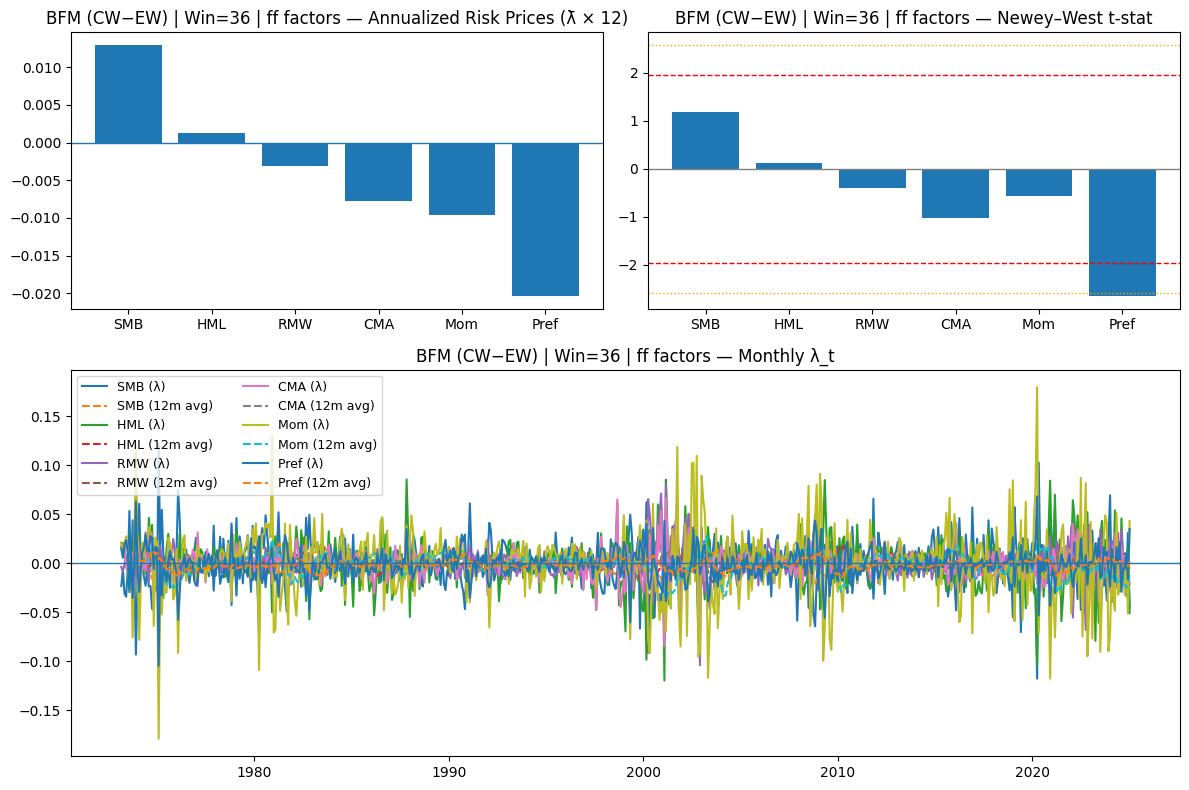

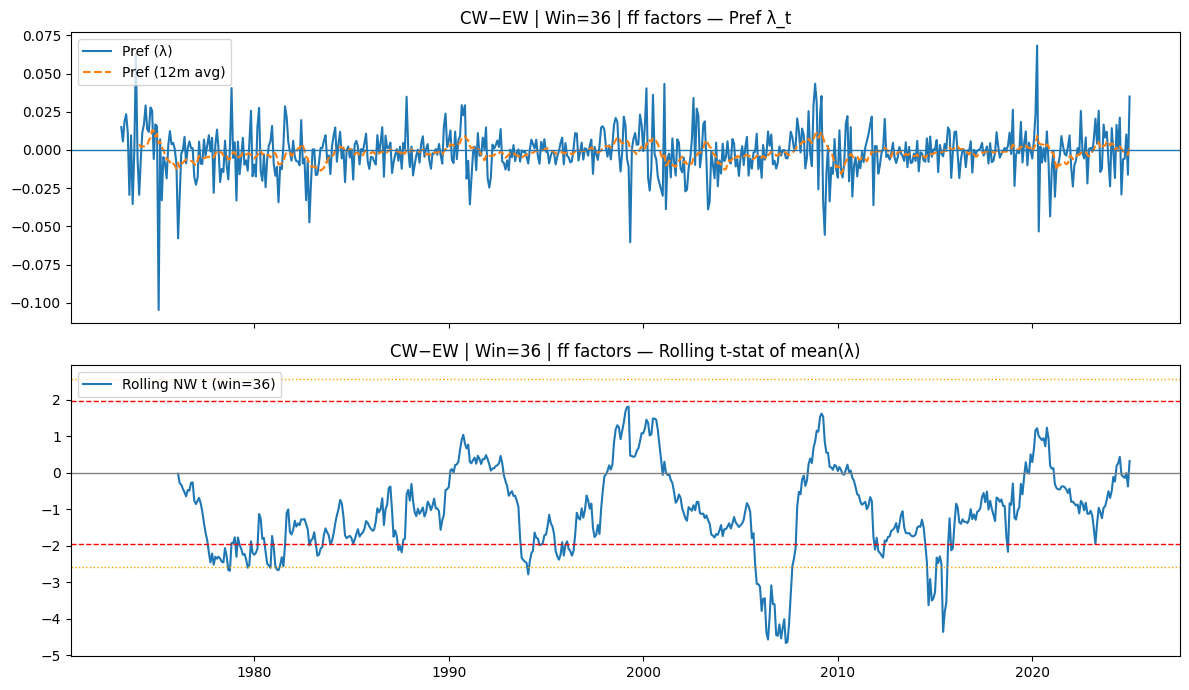


=== Rolling BFM — CW−EBC | Win=36 | Factors=ff factors ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0007,-0.0085,-1.1075
HML,0.0001,0.0017,0.1427
Mom,-0.0010,-0.0119,-0.6673
Pref,-0.0011,-0.0134,-2.0301
RMW,-0.0003,-0.0031,-0.3958
SMB,0.0011,0.0136,1.1373


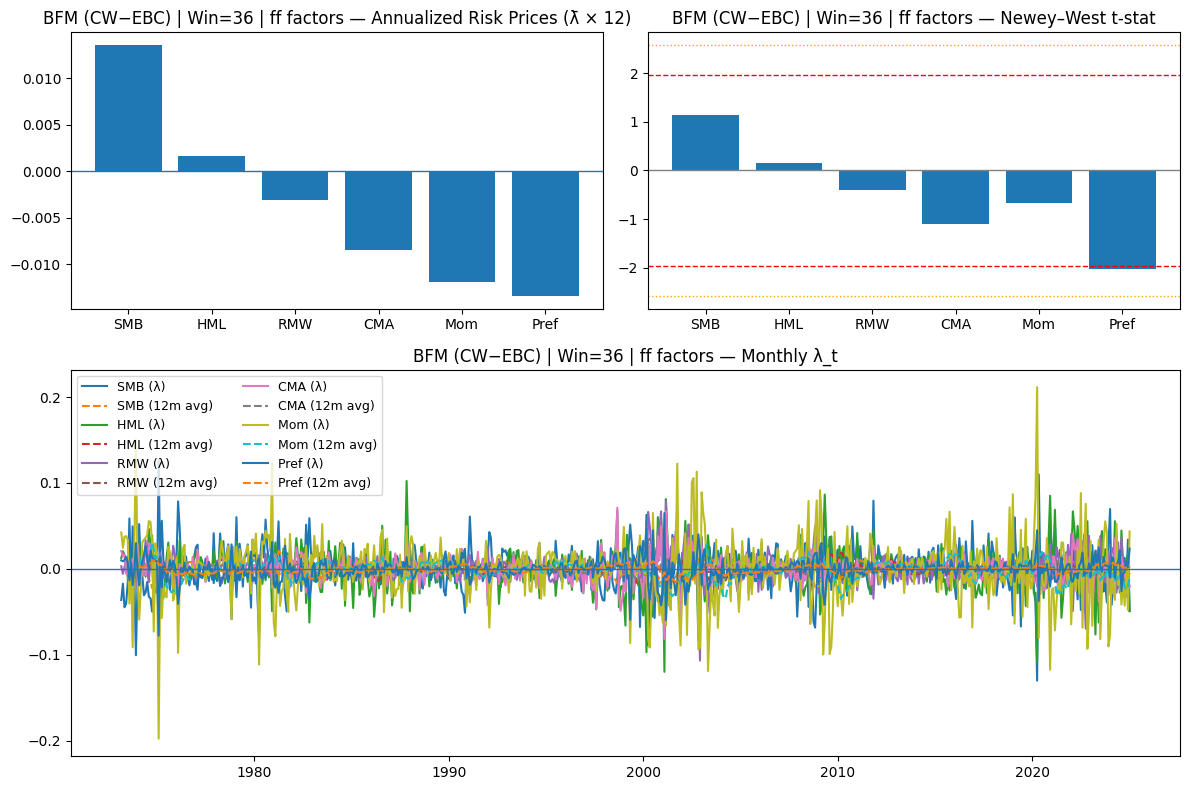

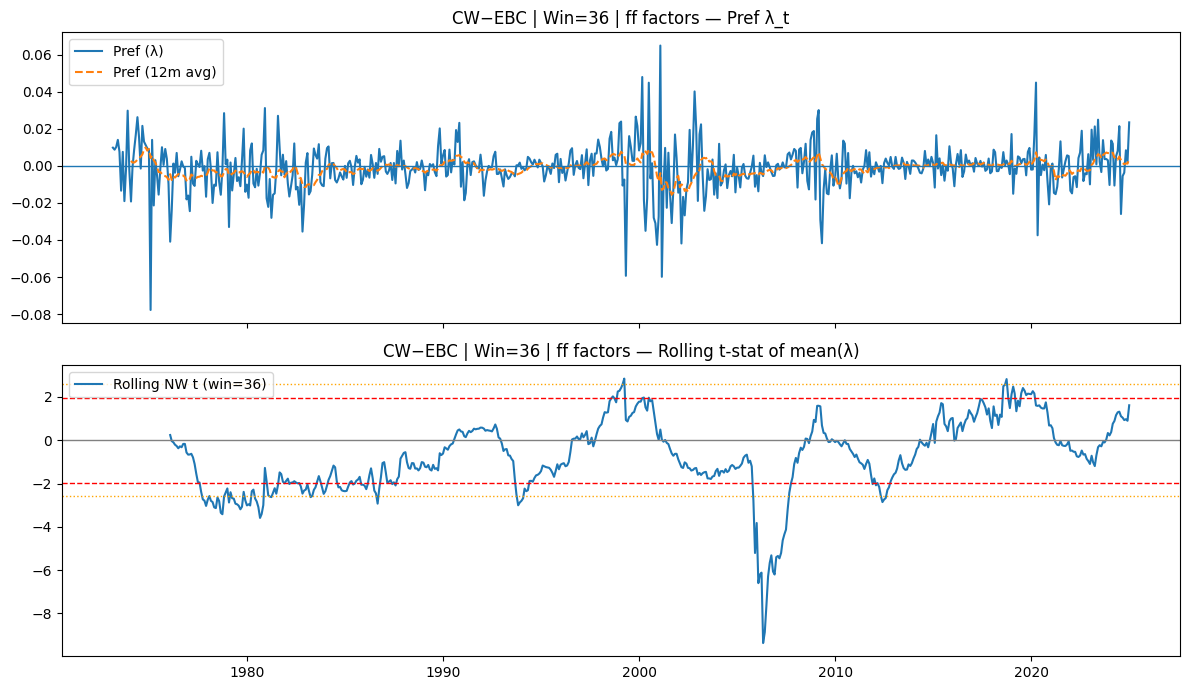


=== Rolling BFM — CW−HRP | Win=36 | Factors=ff factors ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0007,-0.0089,-1.1441
HML,0.0001,0.0007,0.0605
Mom,-0.0008,-0.0092,-0.5174
Pref,-0.0003,-0.0032,-0.5269
RMW,-0.0004,-0.0046,-0.5952
SMB,0.0014,0.0173,1.4588


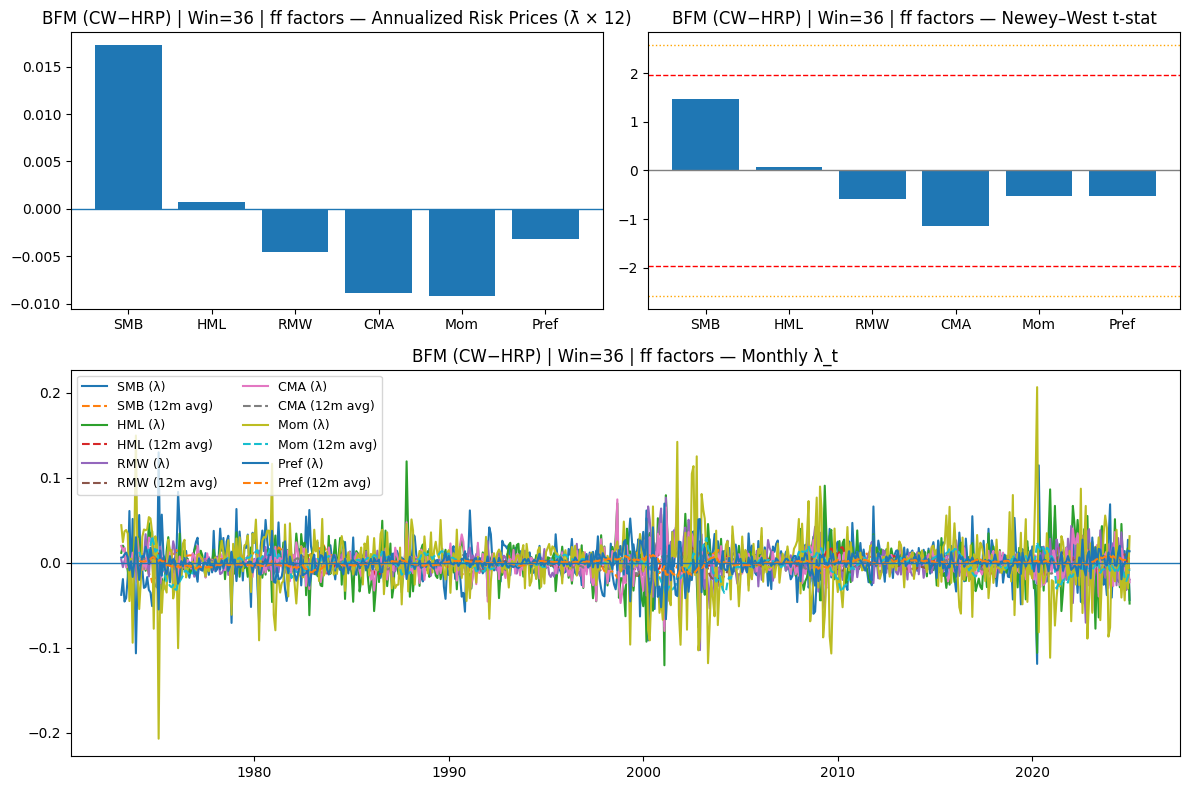

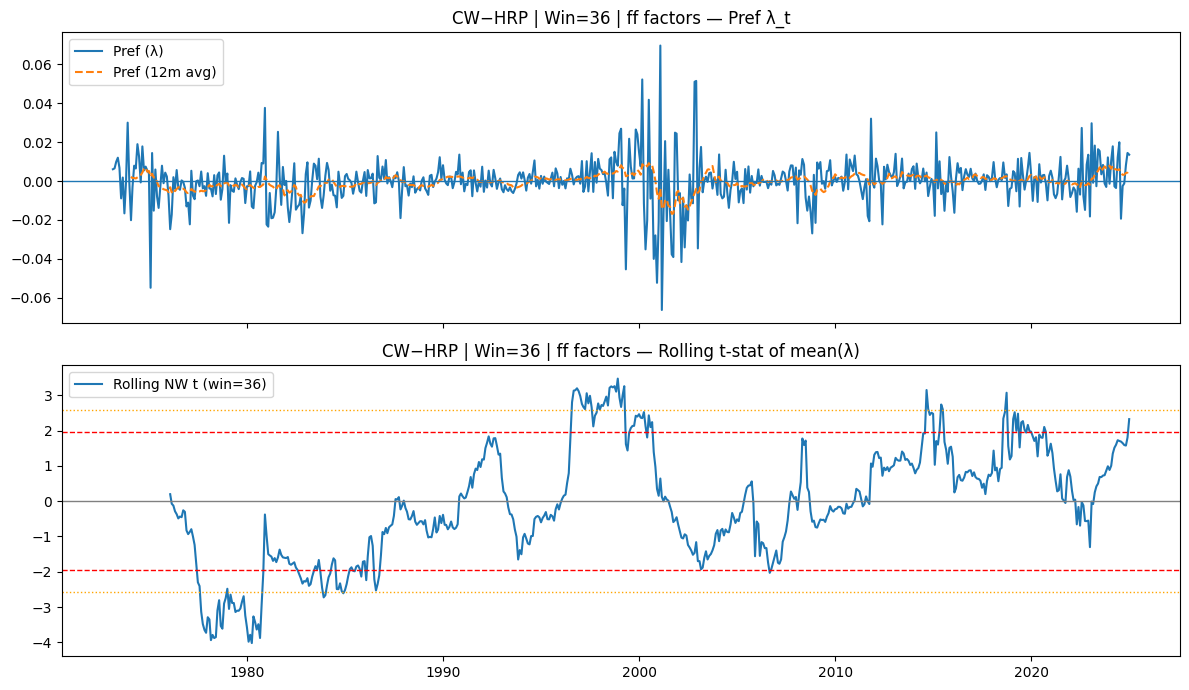

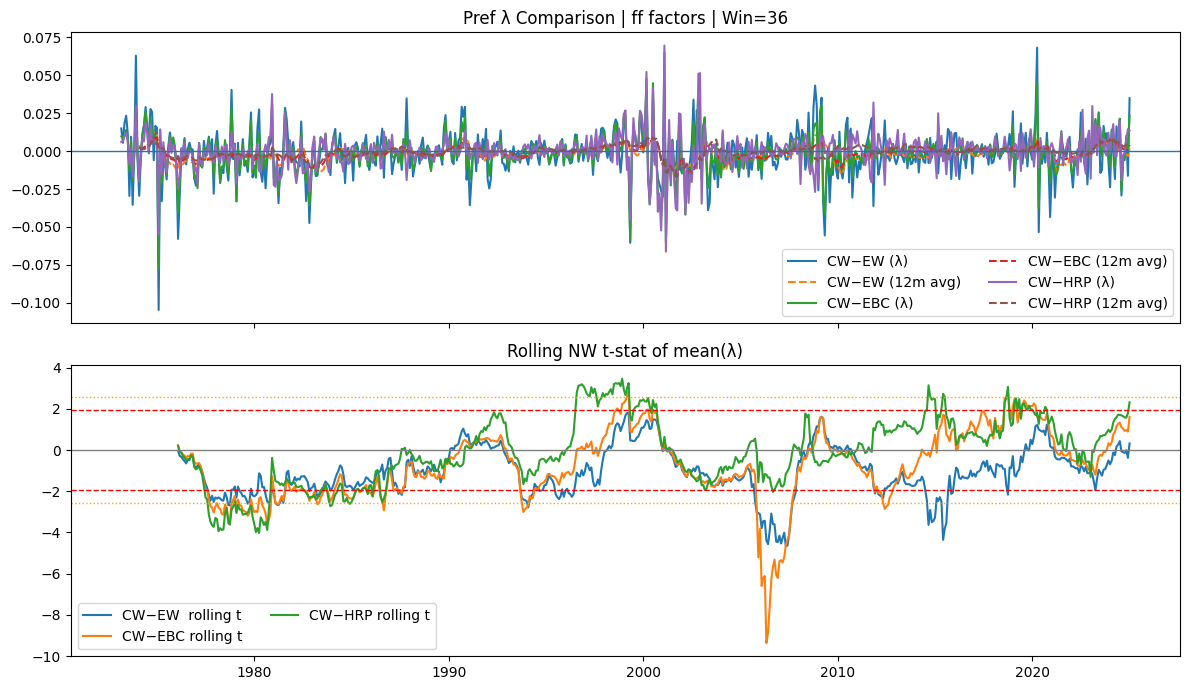

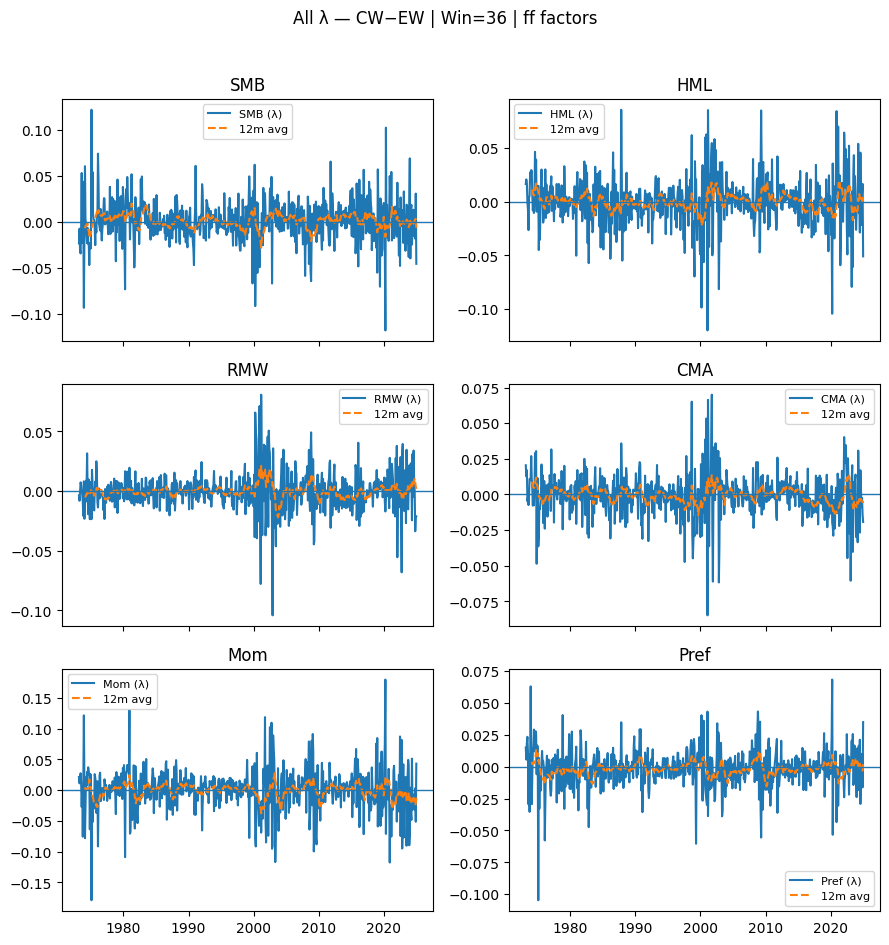

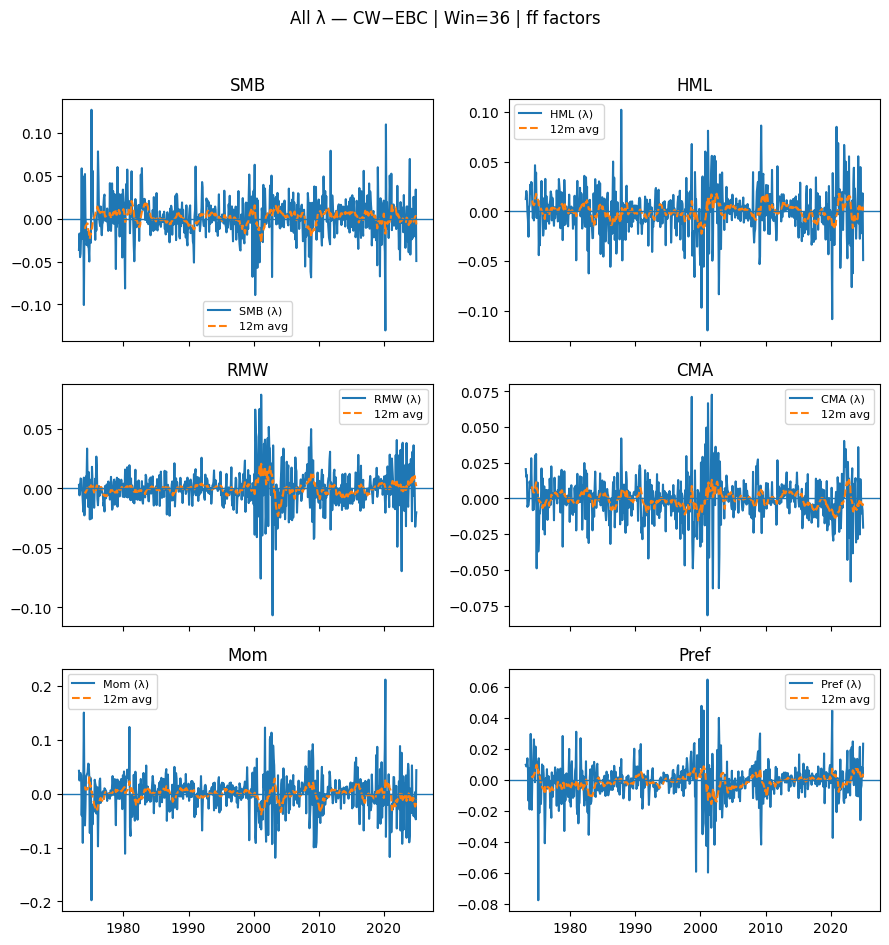

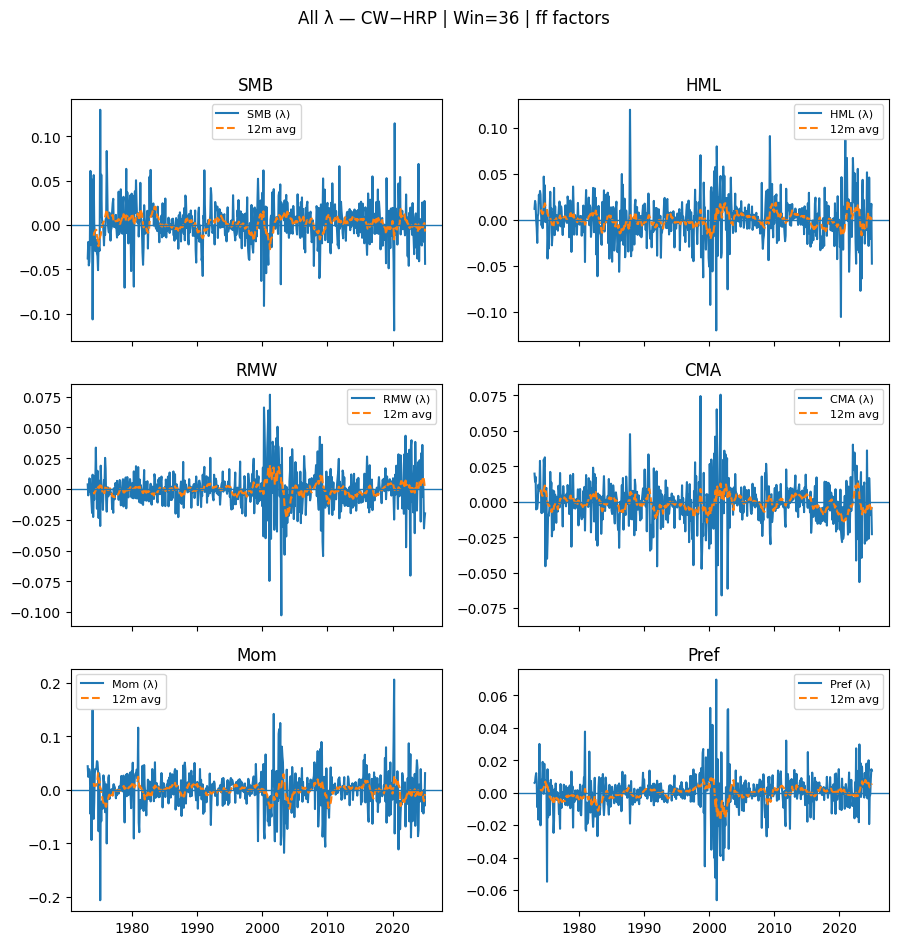

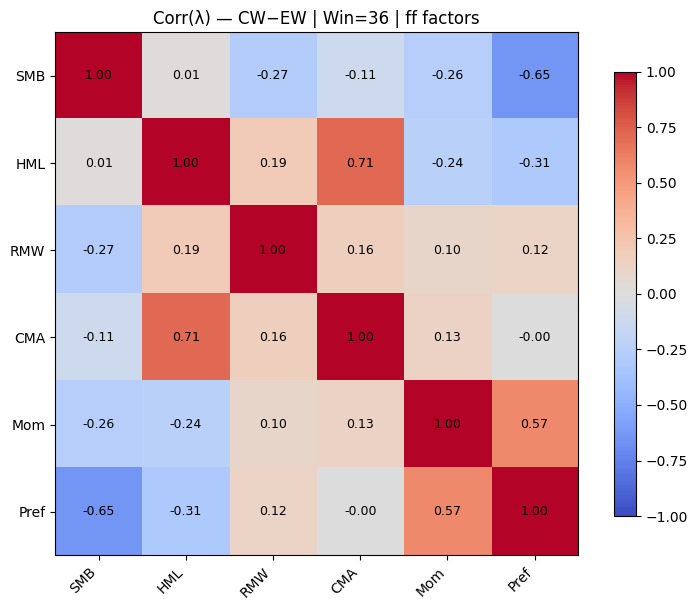

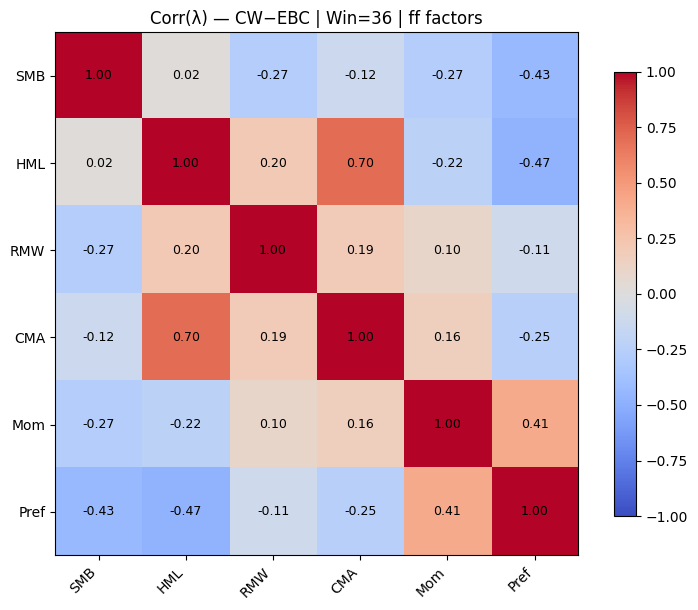

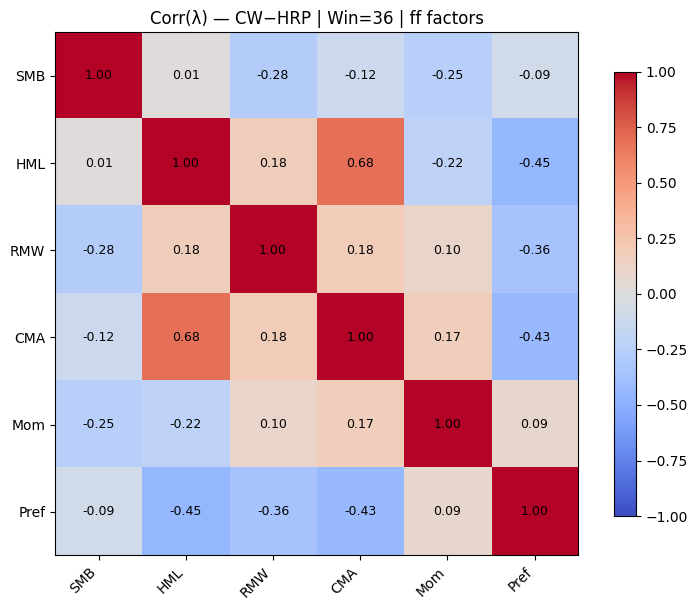


=== Rolling BFM — CW−EW | Win=60 | Factors=ff factors ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0012,-0.0140,-1.6284
HML,-0.0002,-0.0023,-0.1821
Mom,-0.0008,-0.0101,-0.5485
Pref,-0.0023,-0.0280,-3.5428
RMW,-0.0001,-0.0012,-0.1282
SMB,0.0020,0.0234,1.9026


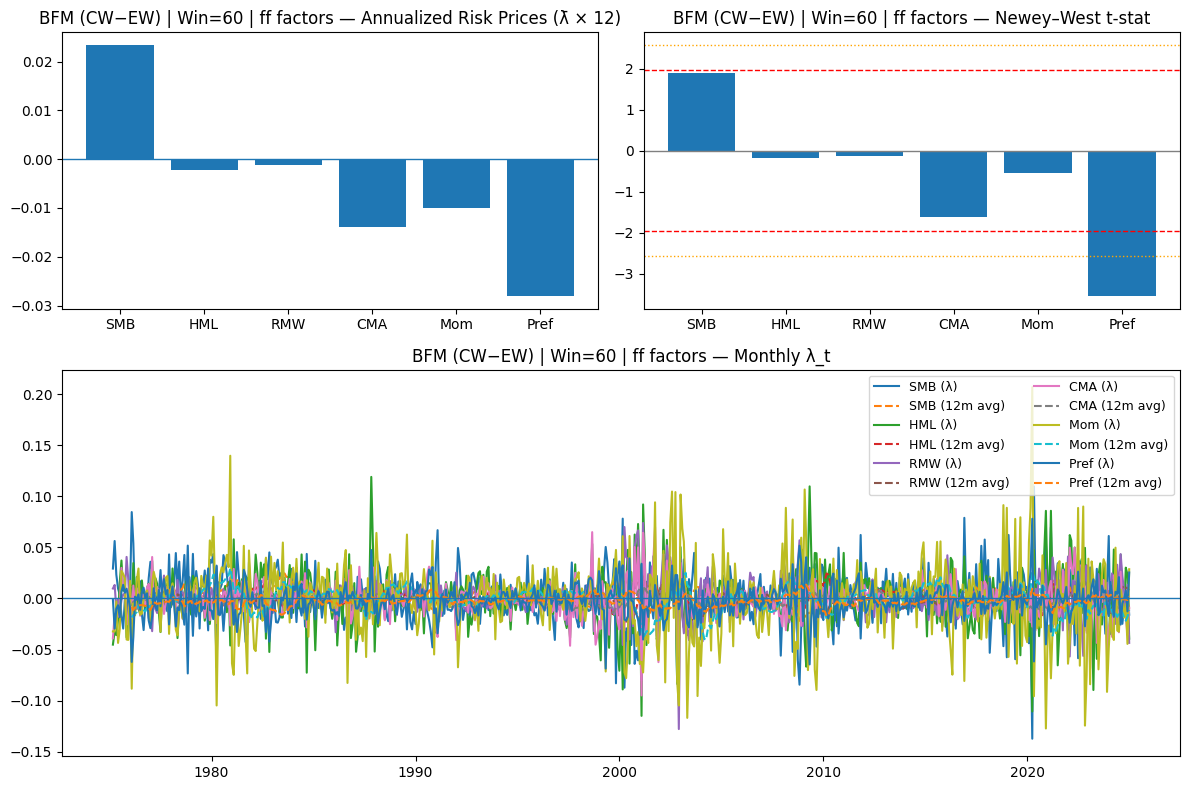

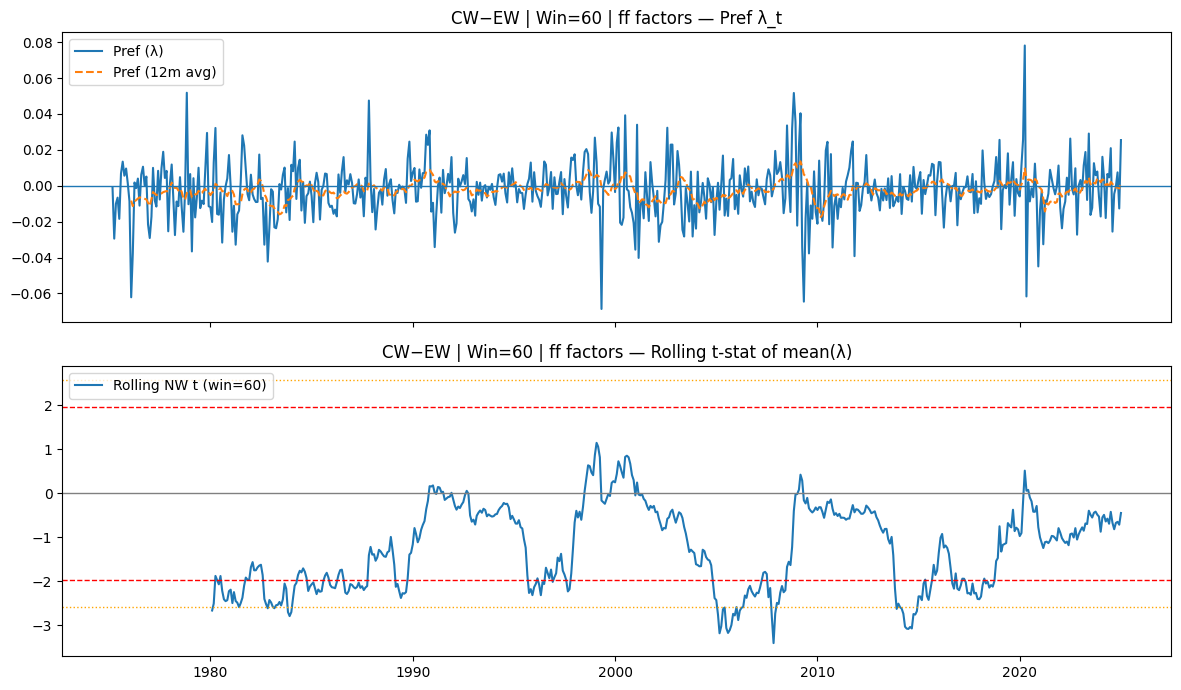


=== Rolling BFM — CW−EBC | Win=60 | Factors=ff factors ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0014,-0.0164,-1.8869
HML,-0.0004,-0.0043,-0.3398
Mom,-0.0017,-0.0201,-1.0578
Pref,-0.0017,-0.0202,-2.8849
RMW,-0.0003,-0.0032,-0.3382
SMB,0.0022,0.0266,2.0227


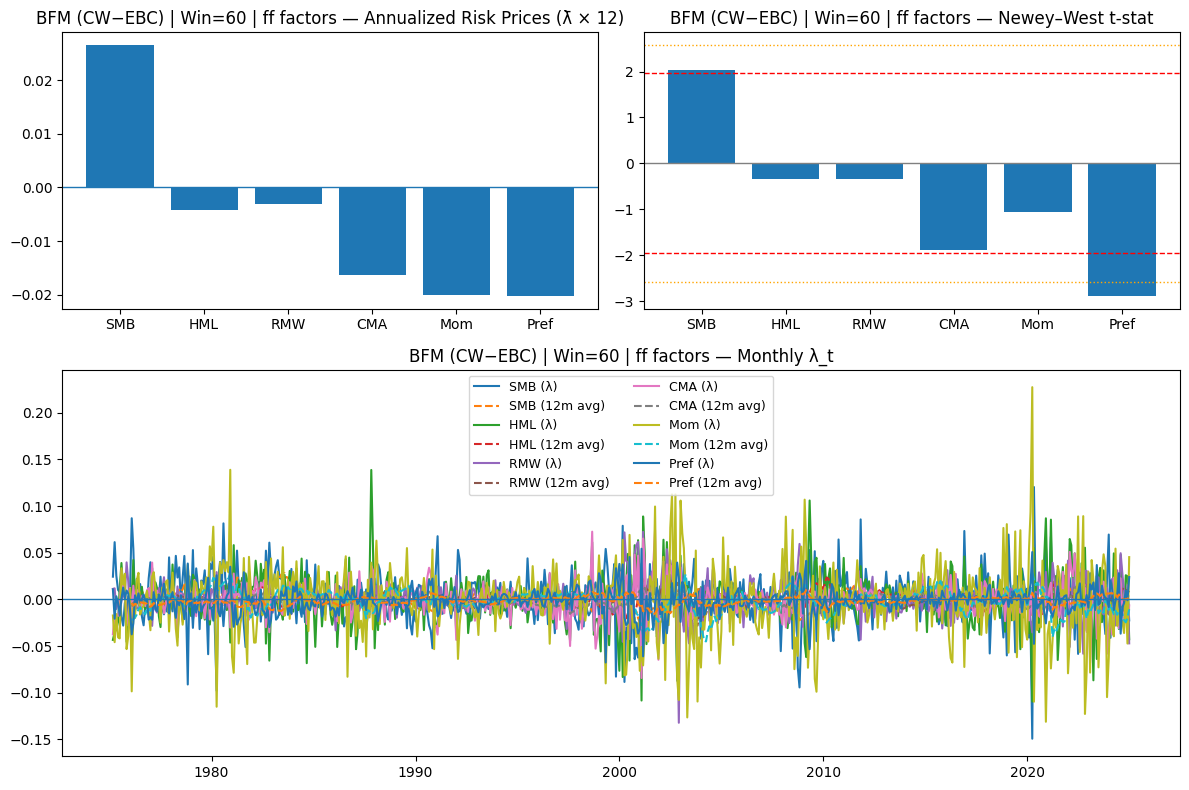

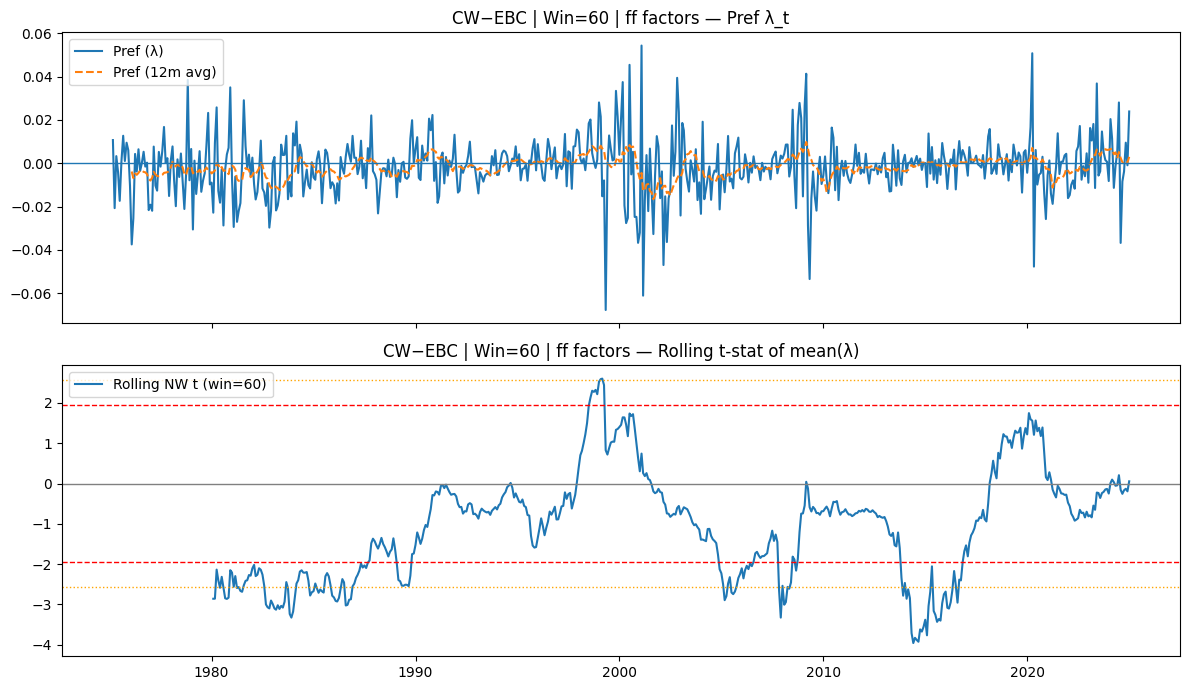


=== Rolling BFM — CW−HRP | Win=60 | Factors=ff factors ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0014,-0.0162,-1.8624
HML,-0.0003,-0.0032,-0.2502
Mom,-0.0014,-0.0166,-0.8883
Pref,-0.0007,-0.0085,-1.2737
RMW,-0.0004,-0.0051,-0.5521
SMB,0.0028,0.0333,2.6034


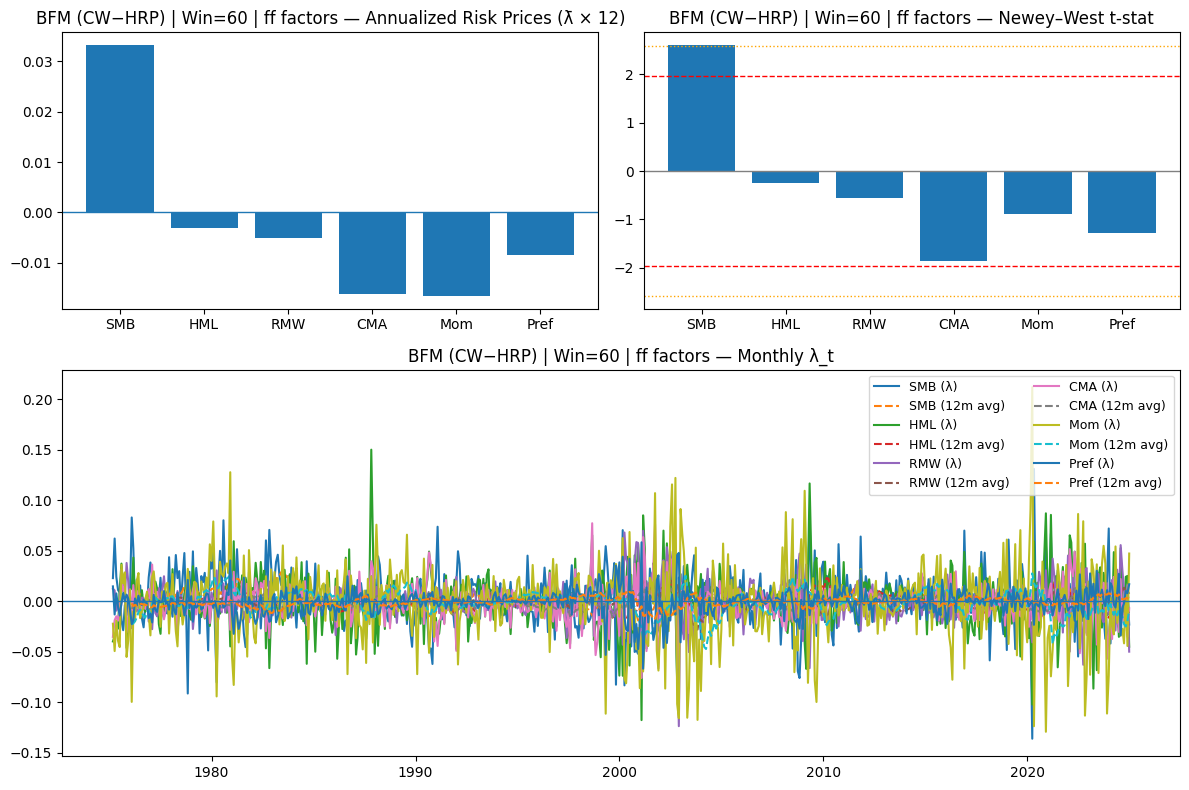

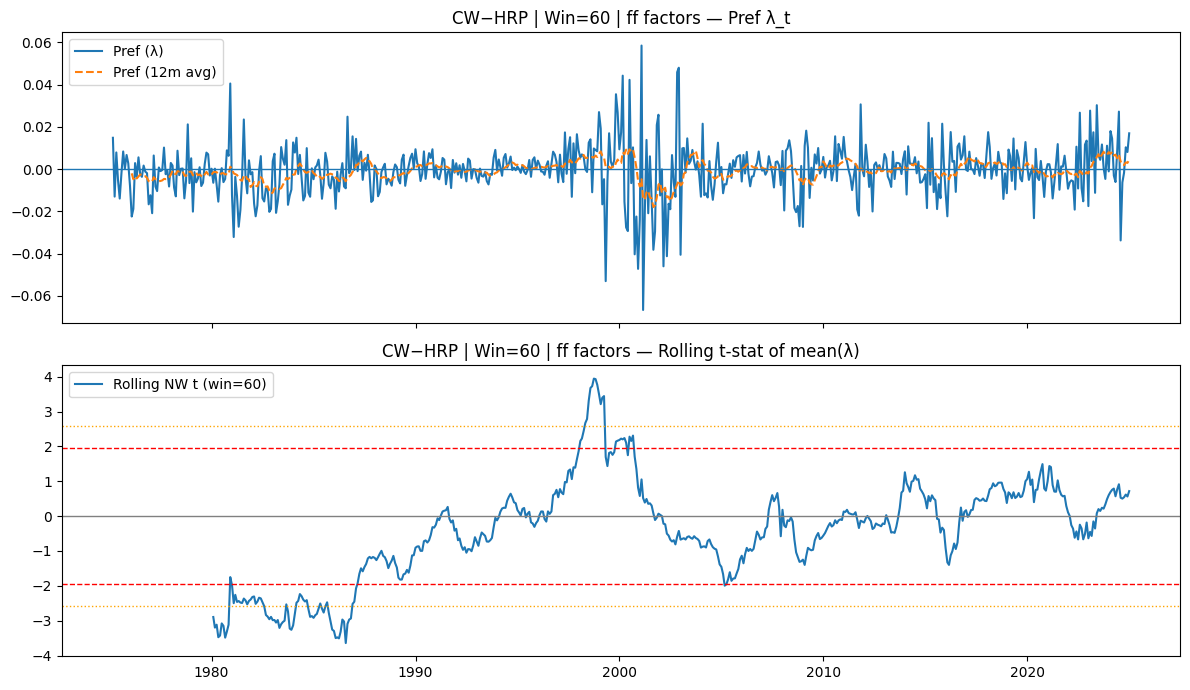

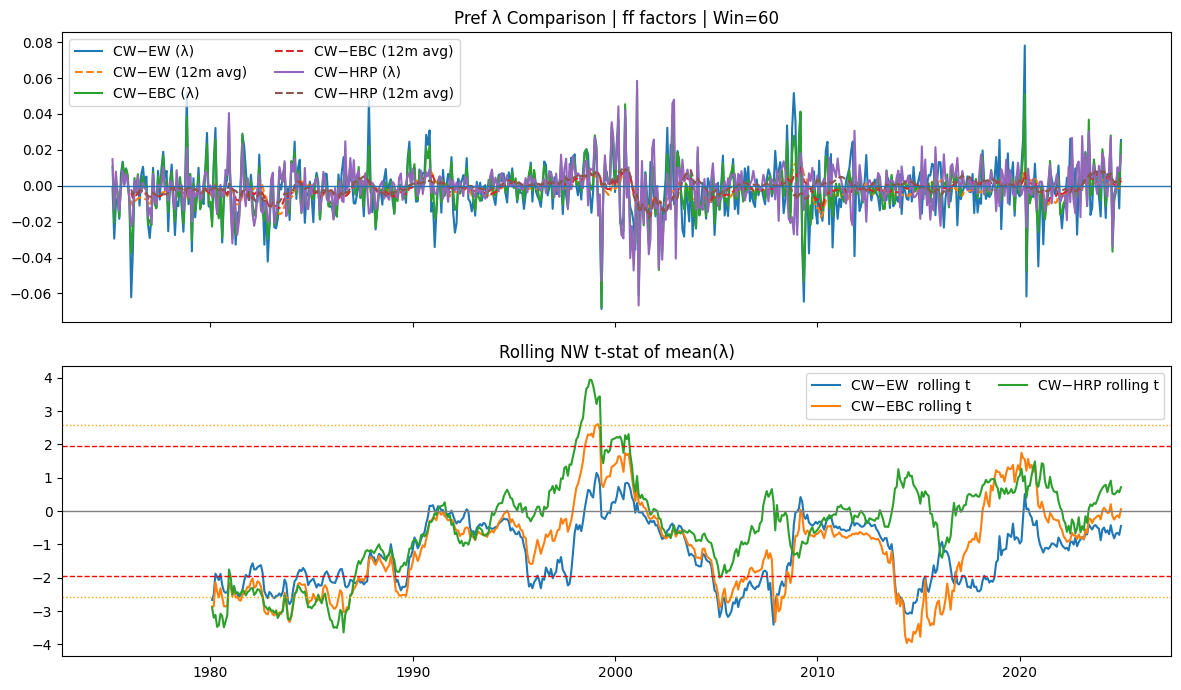

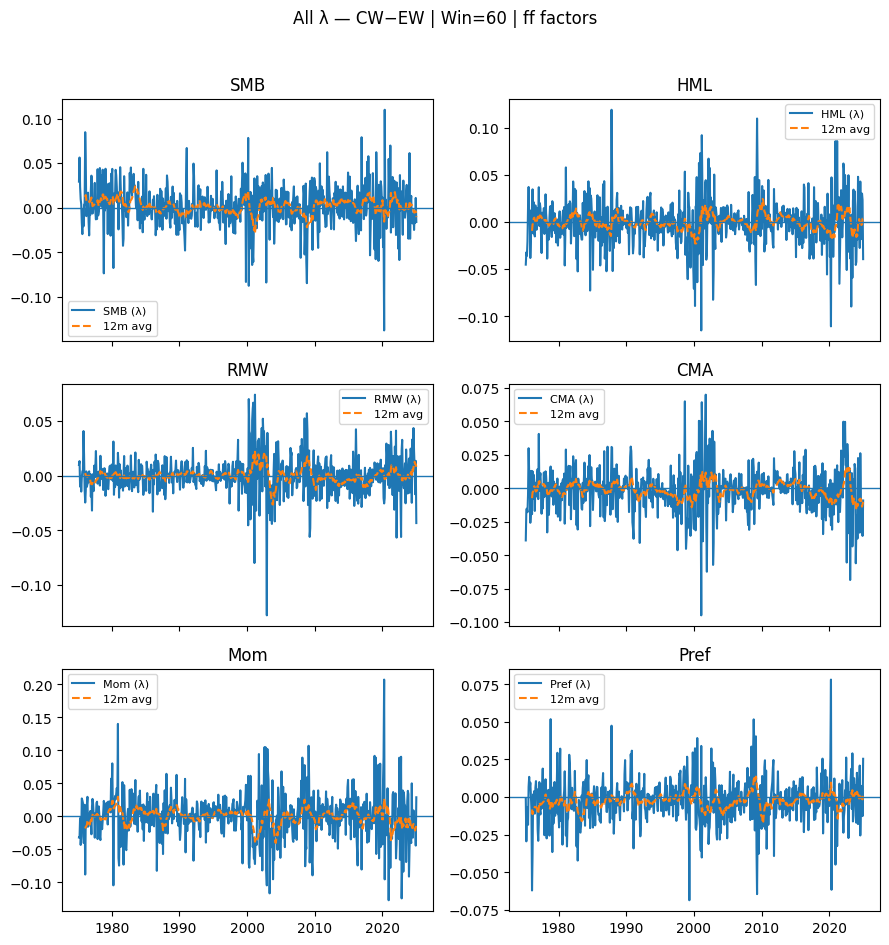

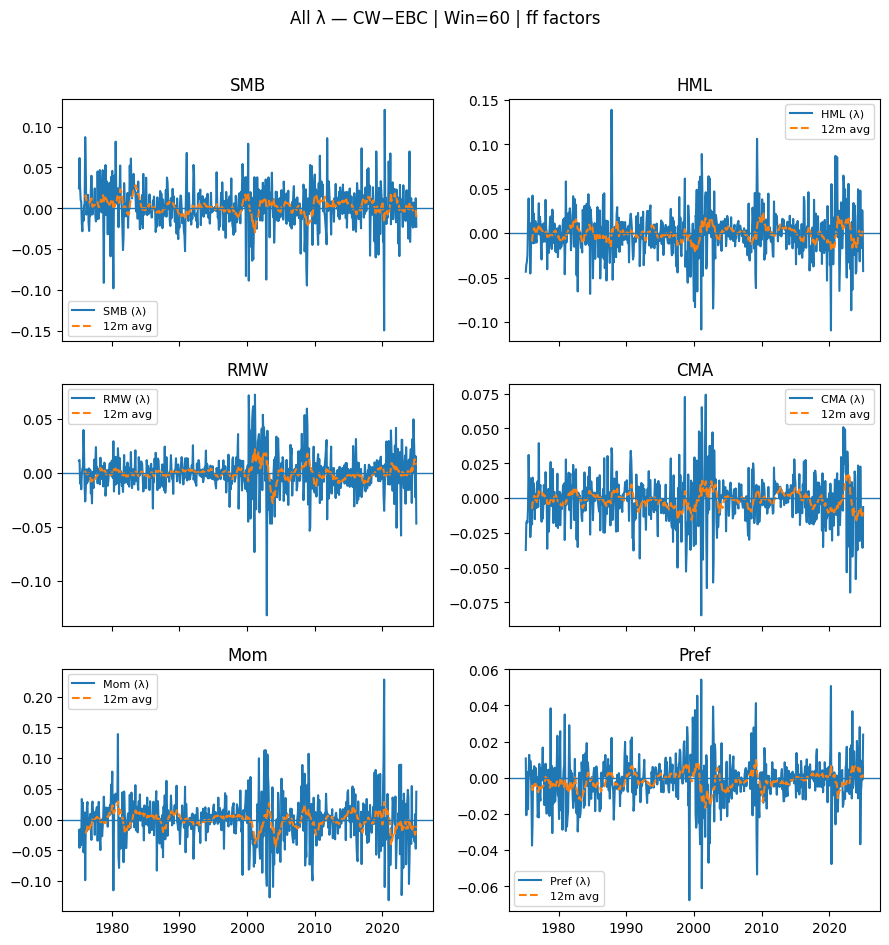

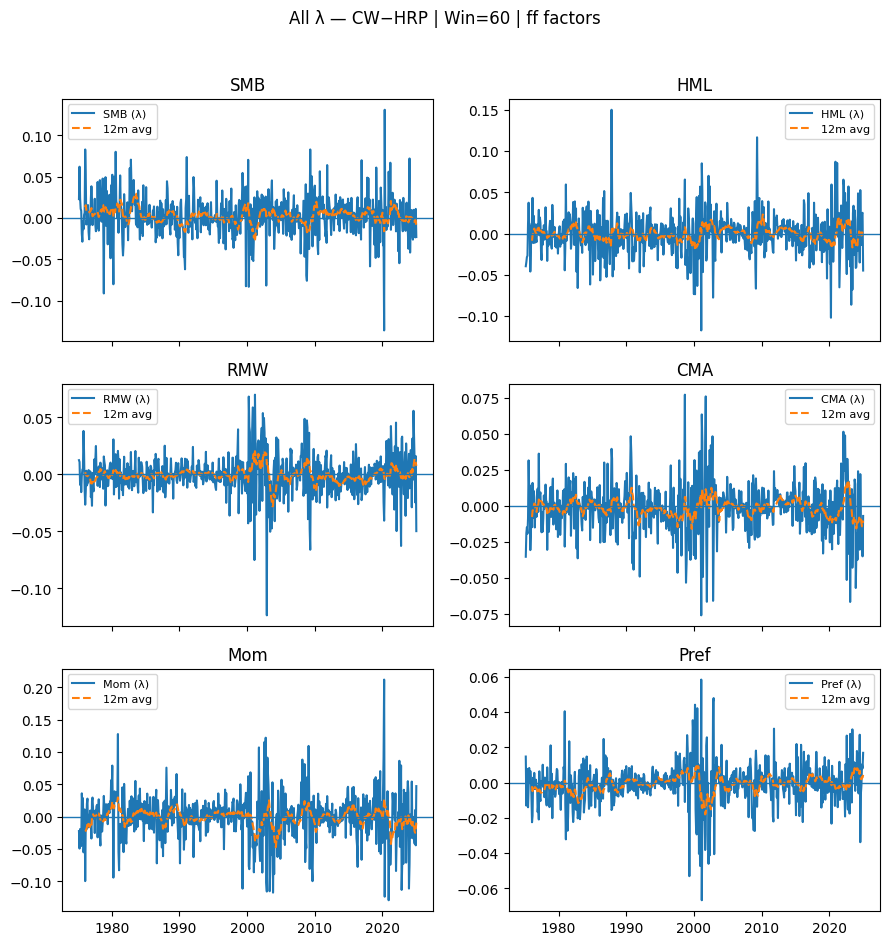

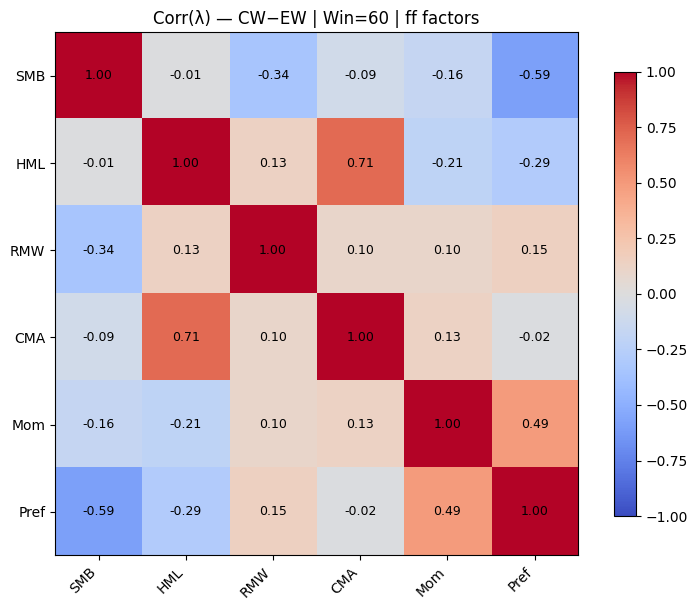

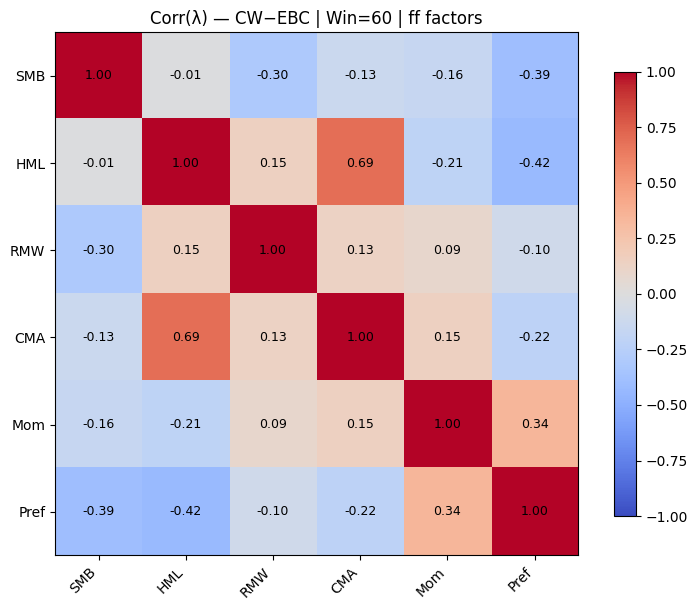

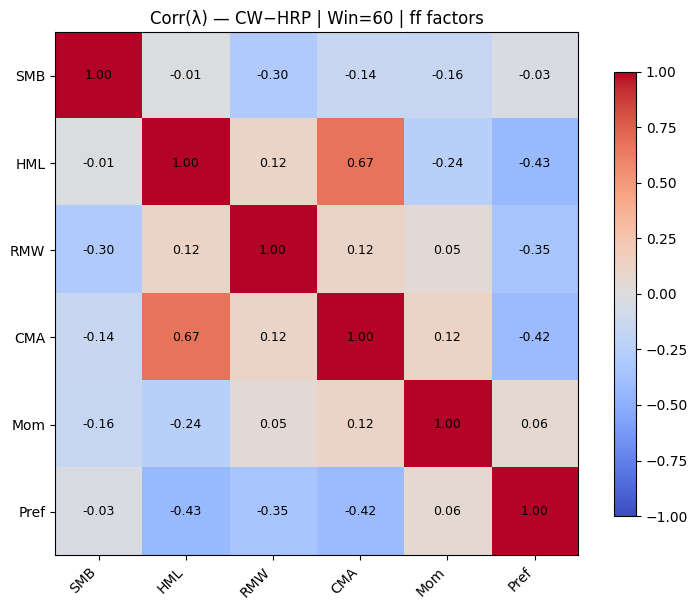


=== Pref risk price comparison across windows (rolling) ===


,lambda_mean_month,lambda_mean_annual,t_NW
CW−EW | 36m,-0.0017,-0.0204,-2.6480
CW−EBC | 36m,-0.0011,-0.0134,-2.0301
CW−HRP | 36m,-0.0003,-0.0032,-0.5269
CW−EW | 60m,-0.0023,-0.0280,-3.5428
CW−EBC | 60m,-0.0017,-0.0202,-2.8849
CW−HRP | 60m,-0.0007,-0.0085,-1.2737


In [35]:
fac_tag = "ff factors"
cw_ew  = pref_m["cw-ew"].copy()      
cw_ebc = pref_m["cw-ebc"].copy()
cw_hrp = pref_m["cw-hrp"].copy()

all_pref_rows = []

for WIN in WINDOWS:
    _ridge = (None if not USE_RIDGE else ("auto" if RIDGE_ALPHA is None else float(RIDGE_ALPHA)))

    # ---- CW−EW ----
    sum_ew, Lambda_ew = rolling_bfm(
        rets=rets, ff=ff, pref_series=cw_ew,
        window=WIN, ridge=_ridge, orthogonalize=ORTHO_PREF,
        factors=factors, nw_maxlags=NW_MAXLAGS
    )
    print(f"\n=== Rolling BFM — CW−EW | Win={WIN} | Factors={fac_tag} ===")
    display(sum_ew.round(4))
    plot_bfm_all(sum_ew, Lambda_ew, title=f"BFM (CW−EW) | Win={WIN} | {fac_tag}", factors=factors)
    plot_lambda_and_t_series(Lambda_ew, factor="Pref", roll_win=WIN,
                             nw_maxlags=NW_MAXLAGS, title=f"CW−EW | Win={WIN} | {fac_tag}")

    # ---- CW−EBC ----
    sum_ebc, Lambda_ebc = rolling_bfm(
        rets=rets, ff=ff, pref_series=cw_ebc,
        window=WIN, ridge=_ridge, orthogonalize=ORTHO_PREF,
        factors=factors, nw_maxlags=NW_MAXLAGS
    )
    print(f"\n=== Rolling BFM — CW−EBC | Win={WIN} | Factors={fac_tag} ===")
    display(sum_ebc.round(4))
    plot_bfm_all(sum_ebc, Lambda_ebc, title=f"BFM (CW−EBC) | Win={WIN} | {fac_tag}", factors=factors)
    plot_lambda_and_t_series(Lambda_ebc, factor="Pref", roll_win=WIN,
                             nw_maxlags=NW_MAXLAGS, title=f"CW−EBC | Win={WIN} | {fac_tag}")

    # ---- CW−HRP ----
    sum_hrp, Lambda_hrp = rolling_bfm(
        rets=rets, ff=ff, pref_series=cw_hrp,
        window=WIN, ridge=_ridge, orthogonalize=ORTHO_PREF,
        factors=factors, nw_maxlags=NW_MAXLAGS
    )
    print(f"\n=== Rolling BFM — CW−HRP | Win={WIN} | Factors={fac_tag} ===")
    display(sum_hrp.round(4))
    plot_bfm_all(sum_hrp, Lambda_hrp, title=f"BFM (CW−HRP) | Win={WIN} | {fac_tag}", factors=factors)
    plot_lambda_and_t_series(Lambda_hrp, factor="Pref", roll_win=WIN,
                             nw_maxlags=NW_MAXLAGS, title=f"CW−HRP | Win={WIN} | {fac_tag}")

    plot_pref_compare(Lambda_ew, Lambda_ebc, Lambda_hrp, win=WIN, title=f"Pref λ Comparison | {fac_tag}")
    
    plot_all_factors_timeseries(Lambda_ew,  title=f"All λ — CW−EW | Win={WIN} | {fac_tag}",  factors=factors)
    plot_all_factors_timeseries(Lambda_ebc, title=f"All λ — CW−EBC | Win={WIN} | {fac_tag}", factors=factors)
    plot_all_factors_timeseries(Lambda_hrp, title=f"All λ — CW−HRP | Win={WIN} | {fac_tag}", factors=factors)
    
    plot_lambda_corr_heatmap(Lambda_ew,  title=f"Corr(λ) — CW−EW | Win={WIN} | {fac_tag}",  factors=factors)
    plot_lambda_corr_heatmap(Lambda_ebc, title=f"Corr(λ) — CW−EBC | Win={WIN} | {fac_tag}", factors=factors)
    plot_lambda_corr_heatmap(Lambda_hrp, title=f"Corr(λ) — CW−HRP | Win={WIN} | {fac_tag}", factors=factors)

    all_pref_rows.extend([
        sum_ew.loc["Pref"].rename(f"CW−EW | {WIN}m"),
        sum_ebc.loc["Pref"].rename(f"CW−EBC | {WIN}m"),
        sum_hrp.loc["Pref"].rename(f"CW−HRP | {WIN}m"),
    ])

compare_pref = pd.DataFrame(all_pref_rows)[["lambda_mean_month", "lambda_mean_annual", "t_NW"]]
print("\n=== Pref risk price comparison across windows (rolling) ===")
display(compare_pref.round(4))